# Credit Risk Modeling - IRB (Vasicek 1-factor Model)



## Uncalibrated Toy Models 

In [24]:
# Modeling Vasicek rate paths 
import numpy as np
import matplotlib.pyplot as plt

def vasicek_model(r0, kappa, theta, sigma, T, dt, n_paths):
    rng = np.random.default_rng(seed=12)

    n_steps = int(T/dt)
    r = np.zeros((n_steps + 1, n_paths))
    r[0,:] = r0

    for i in range(n_steps):
        dw = rng.normal(size=n_paths)
        dr = kappa * (theta - r[i]) * dt + sigma * np.sqrt(dt) * dw
        r[i+1,:] = r[i,:] + dr

    return r


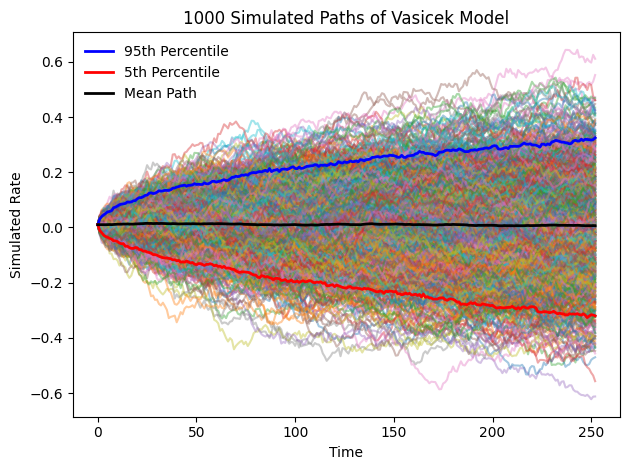

In [25]:
# Toy examples of the parameter (with Uncalibrated Params)
r0 = 0.01
kappa = 0.02
theta = 0.00
sigma = 0.20
T = 1
dt = 1/252
n_paths = 1000


dr = vasicek_model(r0=r0, kappa=kappa, theta=theta, sigma=sigma, T=T, dt=dt, n_paths=n_paths)

# Plotting the model paths
plt.plot(dr, alpha = 0.40)
plt.plot(np.percentile(dr, 95, axis=1), color = 'b', linewidth = 2, label = '95th Percentile')
plt.plot(np.percentile(dr, 5, axis=1), color = 'r', linewidth = 2, label = '5th Percentile')
plt.plot(dr.mean(axis=1), color = 'black', linewidth = 2, label = 'Mean Path')
plt.legend(loc = 'best', frameon = False)
plt.title(f'{n_paths} Simulated Paths of Vasicek Model')
plt.xlabel('Time')
plt.ylabel('Simulated Rate')
plt.tight_layout()
plt.show()


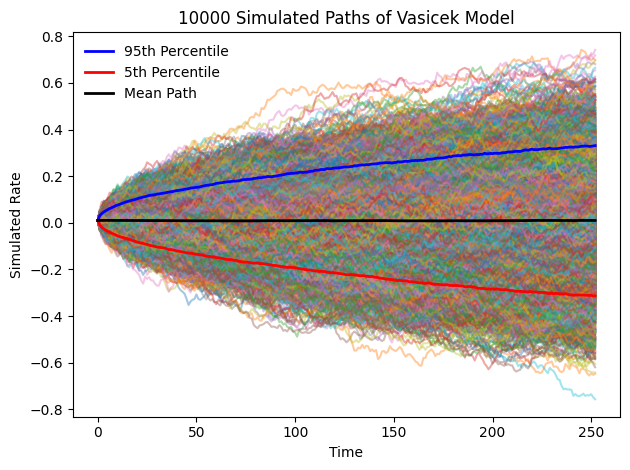

In [26]:
# For cross folder usage of the functions 
import sys
import os
sys.path.append(os.path.abspath('src'))
from vasicek_model import vasicek_model_func

r0 = 0.01
kappa = 0.02
theta = 0.00
sigma = 0.20
T = 1
dt = 1/252
n_paths = 10_000

dr = vasicek_model_func(r0=r0, kappa=kappa, theta=theta, sigma=sigma, T=T, dt=dt, n_paths=n_paths)

# Plotting the model paths
plt.plot(dr, alpha = 0.40)
plt.plot(np.percentile(dr, 95, axis=1), color = 'b', linewidth = 2, label = '95th Percentile')
plt.plot(np.percentile(dr, 5, axis=1), color = 'r', linewidth = 2, label = '5th Percentile')
plt.plot(dr.mean(axis=1), color = 'black', linewidth = 2, label = 'Mean Path')
plt.legend(loc = 'best', frameon = False)
plt.title(f'{n_paths} Simulated Paths of Vasicek Model')
plt.xlabel('Time')
plt.ylabel('Simulated Rate')
plt.tight_layout()
plt.show()

=========== RESULTS ============
Theoretical EL: 9,000.00
Simulated EL: 1,945.44
Unexpected Loss: -2,463.30
VaR: 6,536.70
Expected Shortfall (ES): 7,182.62


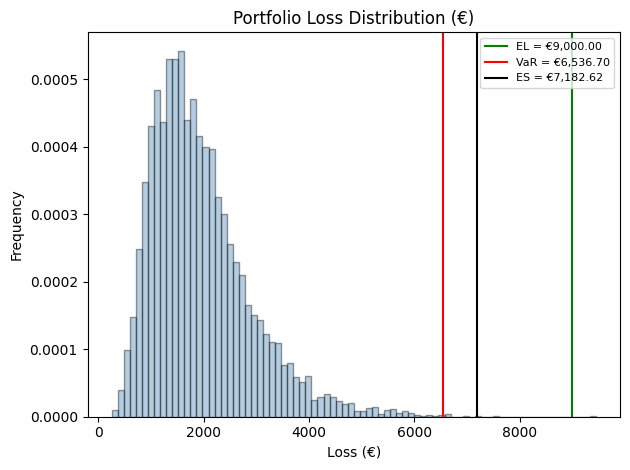

In [27]:
from scipy.stats import norm

# IRB model parameters
def calc_portolio_loss(pd_unconditional, lgd, ead, rho, r_paths):
    default_threshold = norm.ppf(pd_unconditional)
    pd_conditional = norm.cdf((default_threshold - np.sqrt(rho)* r_paths) / np.sqrt( 1 - rho))
    portfolio_loss = pd_conditional * lgd * ead

    return portfolio_loss

pd_unconditional = 0.02
lgd = 0.45
ead = 1_000_000
rho = 0.40
r_paths = dr[-1,:]

all_portfolio_losses = calc_portolio_loss(pd_unconditional=pd_unconditional, lgd=lgd, ead=ead, rho=rho, r_paths=r_paths)
all_portfolio_losses = np.array(all_portfolio_losses)

expected_loss = pd_unconditional * lgd * ead
wcdr = 0.999
VaR = np.percentile(all_portfolio_losses, wcdr * 100)
ES = all_portfolio_losses[all_portfolio_losses >= VaR].mean()
unexpected_loss = VaR - expected_loss


print("=========== RESULTS ============")
print(f'Theoretical EL: {expected_loss:,.2f}')
print(f'Simulated EL: {all_portfolio_losses.mean():,.2f}')
print(f'Unexpected Loss: {unexpected_loss:,.2f}')
print(f'VaR: {VaR:,.2f}')
print(f'Expected Shortfall (ES): {ES:,.2f}')


# Plotting the portfolio loss 
plt.hist(all_portfolio_losses, bins=80, color = 'steelblue', edgecolor = 'black', density=True, alpha = 0.40)
plt.axvline(expected_loss, color = 'g', label = f'EL = €{expected_loss:,.2f}')
plt.axvline(VaR, color = 'r', label = f'VaR = €{VaR:,.2f}')
plt.axvline(ES, color = 'black', label = f'ES = €{ES:,.2f}')
plt.legend(loc = 'upper right', frameon = True, fontsize = 8)
plt.title('Portfolio Loss Distribution (€)')
plt.xlabel('Loss (€)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


# Calibrating Vasicek Model Parameters & Calculating IRB Capital Requirement

[*********************100%***********************]  1 of 1 completed


 ====== Calibrated Params =====
Kappa: 8.0496
Theta: 0.0006
Sigma: 0.0011
r0: 0.0014
=========== RESULTS ============
Theoretical EL: 9,000.00
Simulated EL: 8,979.73
Unexpected Loss: 80,369.67
VaR: 89,369.67
Expected Shortfall (ES): 99,763.60


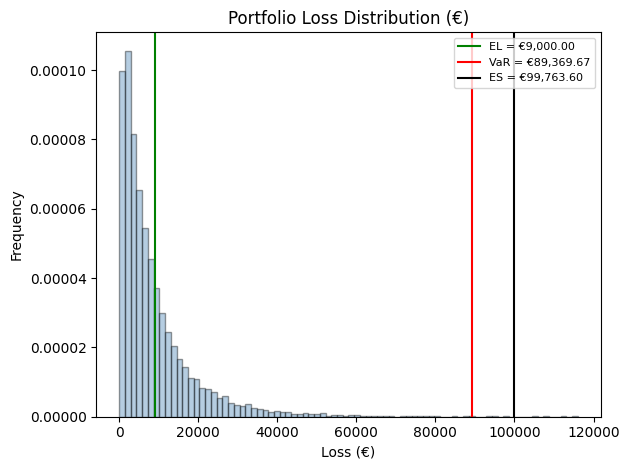

In [28]:
import sys
import os
sys.path.append(os.path.abspath('src'))
from vasicek_model import vasicek_model_func, vasicek_model_params_calc, calc_portolio_loss, basel_rho_calc

# Model params 
tickers = ['^GSPC']
kappa, theta, sigma, r0 = vasicek_model_params_calc(ticker_name='GSPC', tickers=tickers)

# Calibrated paths 
n_paths = 10_000
dt = 1/252
dr = vasicek_model_func(r0=r0, kappa=kappa, theta=theta, sigma=sigma, T=T, dt=dt, n_paths=n_paths)
r_paths = dr[-1,:]


# Portfolio loss distributions 
pd_unconditional = 0.02
lgd = 0.45
ead = 1_000_000
rho = basel_rho_calc(pd_unconditional)
r_paths_ = (r_paths - r_paths.mean()) / r_paths.std()

all_portfolio_losses = calc_portolio_loss(pd_unconditional=pd_unconditional, lgd=lgd, ead=ead, rho=rho, r_paths=r_paths_)
all_portfolio_losses = np.array(all_portfolio_losses)

expected_loss = pd_unconditional * lgd * ead
confidence_level = 0.999
VaR = np.percentile(all_portfolio_losses, confidence_level * 100)
ES = all_portfolio_losses[all_portfolio_losses >= VaR].mean()
unexpected_loss = VaR - expected_loss



# Results and analysis 
print("=========== RESULTS ============")
print(f'Theoretical EL: {expected_loss:,.2f}')
print(f'Simulated EL: {all_portfolio_losses.mean():,.2f}')
print(f'Unexpected Loss: {unexpected_loss:,.2f}')
print(f'VaR: {VaR:,.2f}')
print(f'Expected Shortfall (ES): {ES:,.2f}')


# Plotting the portfolio loss 
plt.hist(all_portfolio_losses, bins=80, color = 'steelblue', edgecolor = 'black', density=True, alpha = 0.40)
plt.axvline(expected_loss, color = 'g', label = f'EL = €{expected_loss:,.2f}')
plt.axvline(VaR, color = 'r', label = f'VaR = €{VaR:,.2f}')
plt.axvline(ES, color = 'black', label = f'ES = €{ES:,.2f}')
plt.legend(loc = 'upper right', frameon = True, fontsize = 8)
plt.title('Portfolio Loss Distribution (€)')
plt.xlabel('Loss (€)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Adding maturity adjustment
def calc_basel_irb_capital(pd_unconditional, lgd, ead, rho, maturity = 2.5):


    # Step 1: Calculate asset correlation (ρ) - Basel formula for corporate exposures
    # ρ = 0.12 * (1 - e^{-50*PD})/(1 - e^{-50}) + 0.24 * (1 - (1 - e^{-50*PD})/(1 - e^{-50}))
    if pd_unconditional <=0:
        rho = 0.12
    else:
        rho = 0.12 * ((1 - np.exp(-50 * pd_unconditional)) / (1 - np.exp(-50))) + \
        0.24 * (1 - ((1 - np.exp(-50 * pd_unconditional)) / (1 - np.exp(-50))))

    # Step 3: Calculate capital requirement before maturity adjustment
    # Formula: K = [LGD * N((N^{-1}(PD) + √ρ * N^{-1}(0.999))/√(1-ρ)) - PD * LGD] * (1 - 1.5 * b)^{-1} * (1 + (M - 2.5) * b)
    maturity_factor = (0.11852 - 0.05478 * np.log(pd_unconditional)) ** 2
    confidence_level = 0.999
    vasicek_factor = norm.cdf(norm.ppf(pd_unconditional) + np.sqrt(rho) * norm.ppf(confidence_level) / np.sqrt(1 - rho))
    capital_before_maturity = (lgd * vasicek_factor) - (lgd * pd_unconditional)

    if maturity is None:
        maturity = 2.5

    maturity_adjustment = (1 + (maturity - 2.5) * maturity_factor) / (1 - 1.5 * maturity_factor)
    capital_percentage = capital_before_maturity * maturity_adjustment
    capital_requirement = capital_percentage * ead

    expected_loss = pd_unconditional * lgd * ead
    provision = np.max([0, expected_loss - capital_requirement])
    risk_weight = capital_percentage * 100

    results = pd.DataFrame({
        'Correlation': [rho],
        'Vasicek Factor': [vasicek_factor],
        'Capital Percentage': [capital_percentage],
        'Capital Requirement': [capital_requirement],
        'Expected Loss': [expected_loss],
        'Provision': [provision],
        'Maturity Factor': [maturity_adjustment],
        'Risk Weight': [risk_weight]

    })

    return results


calc_basel_irb_capital(pd_unconditional = pd_unconditional, lgd = lgd, ead = ead, rho = rho, maturity = 2.5)


,Correlation,Vasicek Factor,Capital Percentage,Capital Requirement,Expected Loss,Provision,Maturity Factor,Risk Weight
0,0.164146,0.246887,0.122444,122443.915749,9000.0,0.0,1.199263,12.244392


# Next Steps 
- Clean the Code for better readability
- Add maturity adjustment and more dynamic correlations params
- Add Monte Carlo Simulation for Portfolio Loss
- Model LGD - Calibrate 
- Model EAD - Calibrate

COMPLETE IRB ANALYSIS RESULTS

📊 INPUT PARAMETERS:
  PD: 2.00%
  LGD: 45.00%
  EAD: €1,000,000
  Correlation (ρ): 0.4000
  Maturity: 3.5 years
  Confidence Level: 99.9%

🏦 REGULATORY CAPITAL (BASEL IRB):
  Vasicek Factor: 0.4490
  Risk Weight: 25.72%
  Capital Requirement: €257,156.59
  Expected Loss: €9,000.00
  Provision: €0.00

📈 SIMULATED ECONOMIC CAPITAL:
  Simulated EL: €9,092.53
  Simulated VaR (99.9%): €195,450.46
  Simulated ES (99.9%): €249,870.02
  Simulated Unexpected Loss: €186,450.46

⚖️ COMPARISON:
  Capital Difference: €-61,706.13
  Capital Ratio (Regulatory/Simulated): 131.57%
  Regulatory Capital Sufficient: True


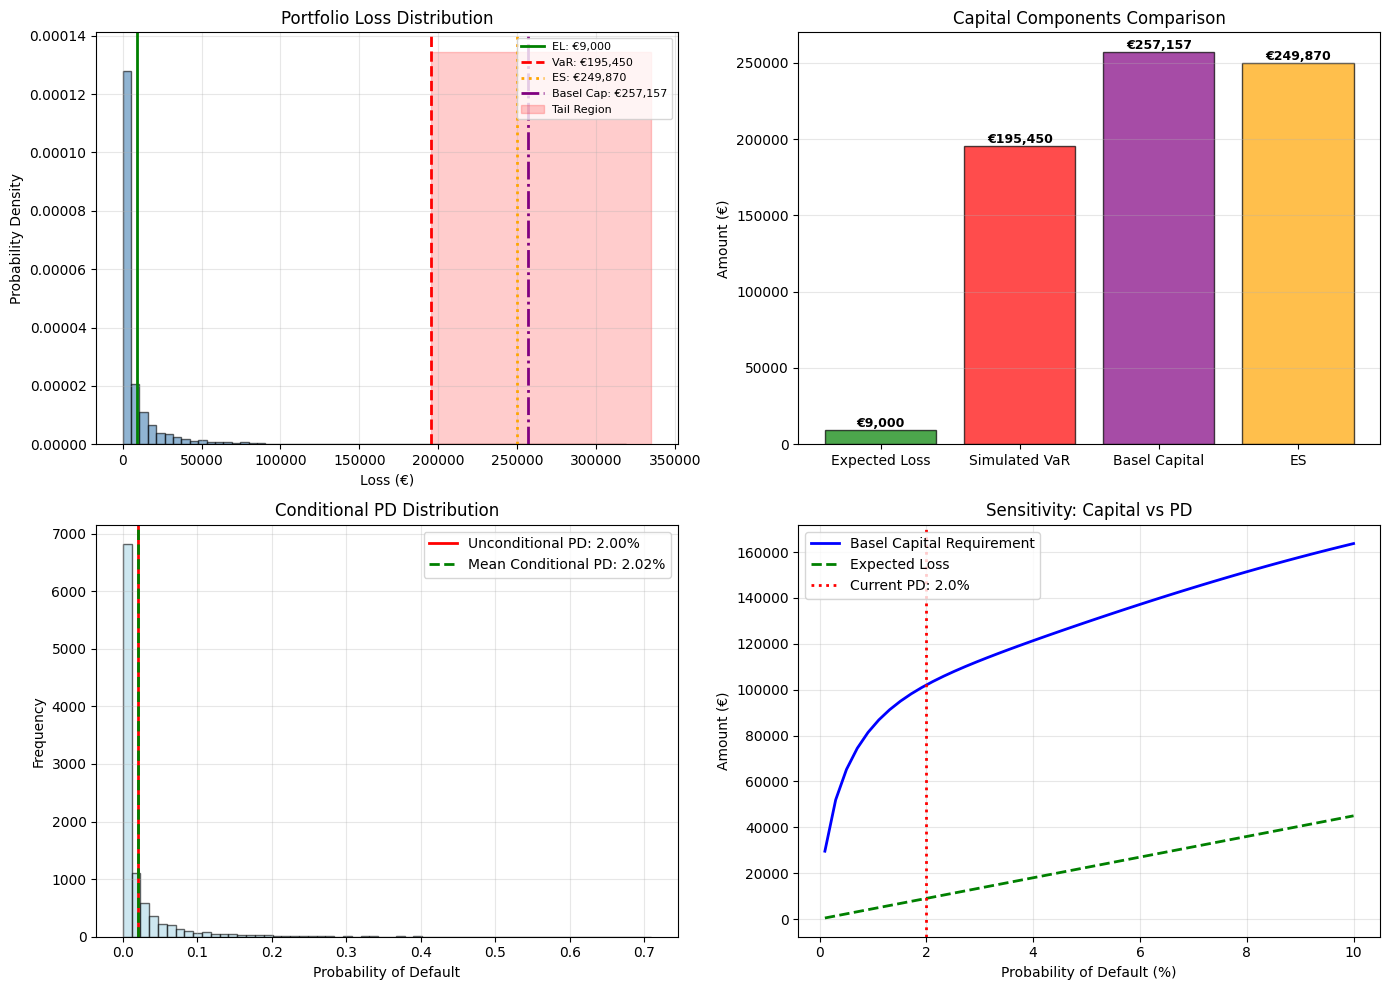

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def calculate_complete_irb_analysis(pd_unconditional, lgd, ead, rho=None, maturity=2.5, 
                                     confidence_level=0.999, r_paths=None):
    """
    Complete IRB analysis combining simulated portfolio losses and Basel regulatory capital.
    
    Parameters:
    - pd_unconditional: Probability of Default
    - lgd: Loss Given Default
    - ead: Exposure at Default
    - rho: Asset correlation (if None, calculated from PD using Basel formula)
    - maturity: Effective maturity (default 2.5 years for corporate)
    - confidence_level: Confidence level for VaR/ES (default 99.9%)
    - r_paths: Simulated systematic risk factor paths (if None, only regulatory capital calculated)
    
    Returns:
    - Dictionary with all results including both simulated and regulatory metrics
    """
    
    # ============================================================================
    # PART 1: BASEL REGULATORY CAPITAL CALCULATION
    # ============================================================================
    
    # Step 1: Calculate or use provided asset correlation
    if rho is None:
        if pd_unconditional <= 0:
            correlation = 0.12
        else:
            correlation = 0.12 * ((1 - np.exp(-50 * pd_unconditional)) / (1 - np.exp(-50))) + \
                          0.24 * (1 - ((1 - np.exp(-50 * pd_unconditional)) / (1 - np.exp(-50))))
    else:
        correlation = rho
    
    # Step 2: Calculate maturity adjustment factor (b)
    if pd_unconditional > 0 and pd_unconditional < 1:
        b_factor = (0.11852 - 0.05478 * np.log(pd_unconditional)) ** 2
    else:
        b_factor = 0
    
    # Step 3: Calculate Vasicek factor at given confidence level
    vasicek_factor = norm.cdf(
        (norm.ppf(pd_unconditional) + np.sqrt(correlation) * norm.ppf(confidence_level)) / 
        np.sqrt(1 - correlation)
    )
    
    # Step 4: Calculate capital requirement before maturity adjustment
    capital_before_maturity = lgd * (vasicek_factor - pd_unconditional)
    
    # Step 5: Apply maturity adjustment
    if maturity is None:
        maturity = 2.5
    
    maturity_adjustment = (1 + (maturity - 2.5) * b_factor) / (1 - 1.5 * b_factor)
    
    # Step 6: Final regulatory capital metrics
    regulatory_capital_percentage = capital_before_maturity * maturity_adjustment
    regulatory_capital = regulatory_capital_percentage * ead
    
    expected_loss = pd_unconditional * lgd * ead
    provision = np.maximum(0, expected_loss - regulatory_capital)
    risk_weight = regulatory_capital_percentage * 100
    
    # ============================================================================
    # PART 2: SIMULATED PORTFOLIO LOSSES (if r_paths provided)
    # ============================================================================
    
    simulated_results = {}
    
    if r_paths is not None:
        # Calculate conditional PDs and portfolio losses
        default_threshold = norm.ppf(pd_unconditional)
        pd_conditional = norm.cdf(
            (default_threshold - np.sqrt(correlation) * r_paths) / np.sqrt(1 - correlation)
        )
        portfolio_losses = pd_conditional * lgd * ead
        portfolio_losses = np.array(portfolio_losses)
        
        # Calculate simulated risk metrics
        simulated_var = np.percentile(portfolio_losses, confidence_level * 100)
        simulated_es = portfolio_losses[portfolio_losses >= simulated_var].mean()
        simulated_el = portfolio_losses.mean()
        simulated_unexpected_loss = simulated_var - expected_loss
        
        # Calculate capital shortfall/excess
        capital_shortfall = np.maximum(0, simulated_var - regulatory_capital)
        capital_excess = np.maximum(0, regulatory_capital - simulated_var)
        
        simulated_results = {
            'portfolio_losses': portfolio_losses,
            'simulated_var': simulated_var,
            'simulated_es': simulated_es,
            'simulated_el': simulated_el,
            'simulated_unexpected_loss': simulated_unexpected_loss,
            'capital_shortfall': capital_shortfall,
            'capital_excess': capital_excess,
            'pd_conditional_stats': {
                'mean': pd_conditional.mean(),
                'std': pd_conditional.std(),
                'percentile_99_9': np.percentile(pd_conditional, 99.9),
                'percentile_95': np.percentile(pd_conditional, 95),
                'percentile_5': np.percentile(pd_conditional, 5)
            }
        }
    
    # ============================================================================
    # PART 3: COMPILE RESULTS
    # ============================================================================
    
    results = {
        # Regulatory capital metrics
        'regulatory': {
            'correlation': correlation,
            'vasicek_factor': vasicek_factor,
            'b_factor': b_factor,
            'maturity_adjustment': maturity_adjustment,
            'capital_percentage': regulatory_capital_percentage,
            'capital_requirement': regulatory_capital,
            'expected_loss': expected_loss,
            'provision': provision,
            'risk_weight': risk_weight,
            'capital_before_maturity': capital_before_maturity
        },
        
        # Simulation metrics (if available)
        'simulated': simulated_results,
        
        # Input parameters
        'inputs': {
            'pd_unconditional': pd_unconditional,
            'lgd': lgd,
            'ead': ead,
            'rho_provided': rho,
            'maturity': maturity,
            'confidence_level': confidence_level
        },
        
        # Comparison metrics (if simulation available)
        'comparison': {}
    }
    
    # Add comparison metrics if simulation was run
    if r_paths is not None:
        results['comparison'] = {
            'capital_difference': simulated_results['simulated_var'] - regulatory_capital,
            'capital_ratio': regulatory_capital / simulated_results['simulated_var'] if simulated_results['simulated_var'] > 0 else np.nan,
            'is_regulatory_sufficient': regulatory_capital >= simulated_results['simulated_var'],
            'el_difference': simulated_results['simulated_el'] - expected_loss,
            'var_vs_es_ratio': simulated_results['simulated_var'] / simulated_results['simulated_es'] if simulated_results['simulated_es'] > 0 else np.nan
        }
    
    return results

# ============================================================================
# PART 4: VISUALIZATION FUNCTION
# ============================================================================

def plot_irb_analysis_results(results):
    """
    Plot the results from calculate_complete_irb_analysis
    """
    if not results['simulated']:
        print("No simulation data available for plotting")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Portfolio loss distribution
    losses = results['simulated']['portfolio_losses']
    regulatory_cap = results['regulatory']['capital_requirement']
    simulated_var = results['simulated']['simulated_var']
    simulated_es = results['simulated']['simulated_es']
    expected_loss = results['regulatory']['expected_loss']
    
    axes[0, 0].hist(losses, bins=60, color='steelblue', edgecolor='black', density=True, alpha=0.6)
    axes[0, 0].axvline(expected_loss, color='green', linewidth=2, label=f'EL: €{expected_loss:,.0f}')
    axes[0, 0].axvline(simulated_var, color='red', linewidth=2, linestyle='--', label=f'VaR: €{simulated_var:,.0f}')
    axes[0, 0].axvline(simulated_es, color='orange', linewidth=2, linestyle=':', label=f'ES: €{simulated_es:,.0f}')
    axes[0, 0].axvline(regulatory_cap, color='purple', linewidth=2, linestyle='-.', label=f'Basel Cap: €{regulatory_cap:,.0f}')
    axes[0, 0].fill_betweenx([0, axes[0, 0].get_ylim()[1]], simulated_var, axes[0, 0].get_xlim()[1], 
                              alpha=0.2, color='red', label='Tail Region')
    axes[0, 0].set_title('Portfolio Loss Distribution')
    axes[0, 0].set_xlabel('Loss (€)')
    axes[0, 0].set_ylabel('Probability Density')
    axes[0, 0].legend(loc='upper right', fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Capital comparison
    categories = ['Expected Loss', 'Simulated VaR', 'Basel Capital', 'ES']
    values = [expected_loss, simulated_var, regulatory_cap, simulated_es]
    colors_cap = ['green', 'red', 'purple', 'orange']
    bars = axes[0, 1].bar(categories, values, color=colors_cap, alpha=0.7, edgecolor='black')
    axes[0, 1].set_ylabel('Amount (€)')
    axes[0, 1].set_title('Capital Components Comparison')
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for bar, value in zip(bars, values):
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                        f'€{value:,.0f}', ha='center', va='bottom', fontweight='bold', rotation=0, fontsize=9)
    
    # Plot 3: Conditional PD distribution
    pd_conditional = results['simulated']['pd_conditional_stats']
    axes[1, 0].hist(results['simulated']['portfolio_losses'] / (results['inputs']['lgd'] * results['inputs']['ead']), 
                    bins=60, color='lightblue', edgecolor='black', alpha=0.6)
    axes[1, 0].axvline(results['inputs']['pd_unconditional'], color='red', linewidth=2, 
                       label=f'Unconditional PD: {results["inputs"]["pd_unconditional"]:.2%}')
    axes[1, 0].axvline(pd_conditional['mean'], color='green', linewidth=2, linestyle='--',
                       label=f'Mean Conditional PD: {pd_conditional["mean"]:.2%}')
    axes[1, 0].set_title('Conditional PD Distribution')
    axes[1, 0].set_xlabel('Probability of Default')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Sensitivity analysis
    pd_range = np.linspace(0.001, 0.10, 50)
    capital_range = []
    for pd_test in pd_range:
        temp_results = calculate_complete_irb_analysis(
            pd_unconditional=pd_test,
            lgd=results['inputs']['lgd'],
            ead=results['inputs']['ead'],
            rho=None,
            maturity=results['inputs']['maturity'],
            confidence_level=results['inputs']['confidence_level'],
            r_paths=None  # No simulation for sensitivity
        )
        capital_range.append(temp_results['regulatory']['capital_requirement'])
    
    el_range = pd_range * results['inputs']['lgd'] * results['inputs']['ead']
    
    axes[1, 1].plot(pd_range * 100, capital_range, 'b-', linewidth=2, label='Basel Capital Requirement')
    axes[1, 1].plot(pd_range * 100, el_range, 'g--', linewidth=2, label='Expected Loss')
    axes[1, 1].axvline(results['inputs']['pd_unconditional'] * 100, color='red', linestyle=':', 
                       linewidth=2, label=f'Current PD: {results["inputs"]["pd_unconditional"]*100:.1f}%')
    axes[1, 1].set_xlabel('Probability of Default (%)')
    axes[1, 1].set_ylabel('Amount (€)')
    axes[1, 1].set_title('Sensitivity: Capital vs PD')
    axes[1, 1].legend(loc='upper left')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# PART 5: EXAMPLE USAGE
# ============================================================================

# Example with your Vasicek simulation results
if __name__ == "__main__":
    # Your parameters
    pd_unconditional = 0.02
    lgd = 0.45
    ead = 1_000_000
    rho = 0.40
    maturity = 3.5
    
    # Assuming you have r_paths from your Vasicek model simulation
    # r_paths = dr[-1, :]  # Uncomment when you have this
    
    # For demonstration, create sample r_paths if not available
    np.random.seed(42)
    r_paths_demo = np.random.normal(0, 1, 10000)  # Replace with your actual r_paths
    
    # Run complete analysis
    results = calculate_complete_irb_analysis(
        pd_unconditional=pd_unconditional,
        lgd=lgd,
        ead=ead,
        rho=rho,
        maturity=maturity,
        confidence_level=0.999,
        r_paths=r_paths_demo  # Pass your simulated r_paths here
    )
    
    # Print results
    print("="*70)
    print("COMPLETE IRB ANALYSIS RESULTS")
    print("="*70)
    
    print("\n📊 INPUT PARAMETERS:")
    print(f"  PD: {results['inputs']['pd_unconditional']:.2%}")
    print(f"  LGD: {results['inputs']['lgd']:.2%}")
    print(f"  EAD: €{results['inputs']['ead']:,.0f}")
    print(f"  Correlation (ρ): {results['regulatory']['correlation']:.4f}")
    print(f"  Maturity: {results['inputs']['maturity']} years")
    print(f"  Confidence Level: {results['inputs']['confidence_level']*100:.1f}%")
    
    print("\n🏦 REGULATORY CAPITAL (BASEL IRB):")
    print(f"  Vasicek Factor: {results['regulatory']['vasicek_factor']:.4f}")
    print(f"  Risk Weight: {results['regulatory']['risk_weight']:.2f}%")
    print(f"  Capital Requirement: €{results['regulatory']['capital_requirement']:,.2f}")
    print(f"  Expected Loss: €{results['regulatory']['expected_loss']:,.2f}")
    print(f"  Provision: €{results['regulatory']['provision']:,.2f}")
    
    if results['simulated']:
        print("\n📈 SIMULATED ECONOMIC CAPITAL:")
        print(f"  Simulated EL: €{results['simulated']['simulated_el']:,.2f}")
        print(f"  Simulated VaR (99.9%): €{results['simulated']['simulated_var']:,.2f}")
        print(f"  Simulated ES (99.9%): €{results['simulated']['simulated_es']:,.2f}")
        print(f"  Simulated Unexpected Loss: €{results['simulated']['simulated_unexpected_loss']:,.2f}")
        
        print("\n⚖️ COMPARISON:")
        print(f"  Capital Difference: €{results['comparison']['capital_difference']:,.2f}")
        print(f"  Capital Ratio (Regulatory/Simulated): {results['comparison']['capital_ratio']:.2%}")
        print(f"  Regulatory Capital Sufficient: {results['comparison']['is_regulatory_sufficient']}")
        
    
    # Plot results
    plot_irb_analysis_results(results)